BRAIN TUMOR DETECTION


In [ ]:
# Block 1
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D,Flatten, Dense
import cv2

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
train_path = path + "/Training"
test_path = path + "/Testing"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
# Block 5
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
# Block 6
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),   # 🔥 Better than Flatten

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

In [ ]:
# Block 7
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Block 9
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 50s 255ms/step - accuracy: 0.4686 - loss: 1.1239 - val_accuracy: 0.5681 - val_loss: 1.1171
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.6550 - loss: 0.8454 - val_accuracy: 0.6031 - val_loss: 1.0408
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 132ms/step - accuracy: 0.6973 - loss: 0.7438 - val_accuracy: 0.6044 - val_loss: 1.0912
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.7371 - loss: 0.6631 - val_accuracy: 0.6231 - val_loss: 0.9911
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.7595 - loss: 0.6207 - val_accuracy: 0.6769 - val_loss: 0.9312
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.7661 - loss: 0.6108 - val_accuracy: 0.6669 - val_loss: 0.9958
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.7829 - loss: 0.5591 - val_accuracy: 0.6656 - val_loss: 0.9816
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.7905 - loss: 0.5388 

In [ ]:
# Block 10
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6975 - loss: 0.9565
Test Accuracy: 0.6974999904632568


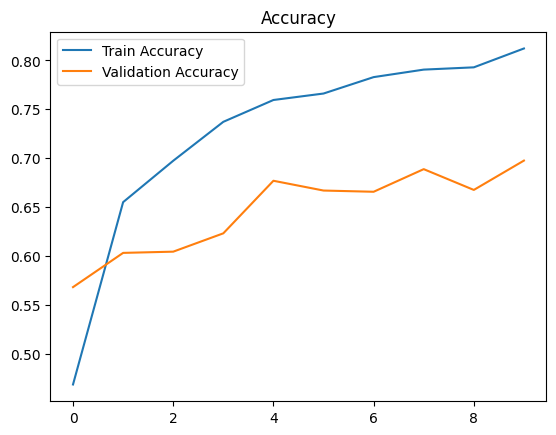

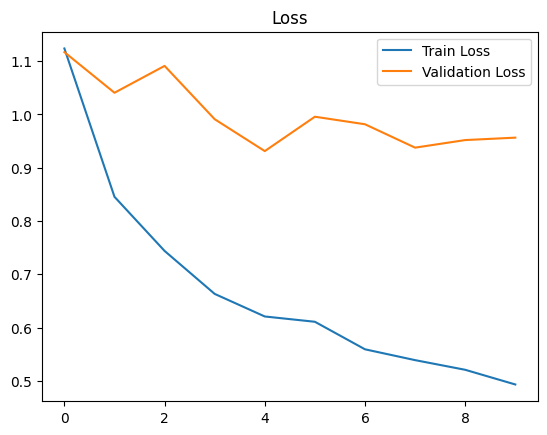

In [ ]:
# Block 11
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()